In [2]:
pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


ÉTAPE 1 — Chargement du DAG et des données
  DAG    : 10 nœuds, 10 liens
  Données: 51,000 lignes, taux fraude = 4.92%

ÉTAPE 2 — Analyse du graphe causal
  ✅ DAG valide (acyclique)

  Ordre topologique de génération :
    🟡 RACINE  Transaction_Amount
    🟡 RACINE  Transaction_Type
    🟡 RACINE  Time_of_Transaction
    🟡 RACINE  Previous_Fraudulent_Transactions
    🟡 RACINE  Account_Age
    🟡 RACINE  Number_of_Transactions_Last_24H
    🟢 enfant  Device_Used
           ← parents : ['Transaction_Type']
    🟢 enfant  Payment_Method
           ← parents : ['Transaction_Type']
    🟢 enfant  Location
           ← parents : ['Device_Used']
    🔴  Fraudulent
           ← parents : ['Location', 'Payment_Method', 'Time_of_Transaction', 'Account_Age', 'Transaction_Amount', 'Number_of_Transactions_Last_24H', 'Previous_Fraudulent_Transactions']

ÉTAPE 4 — Entraînement des mini-modèles SCM
          (un modèle par nœud enfant du DAG)

  ── Device_Used  (type=categorical, parents=['Transaction_Type']

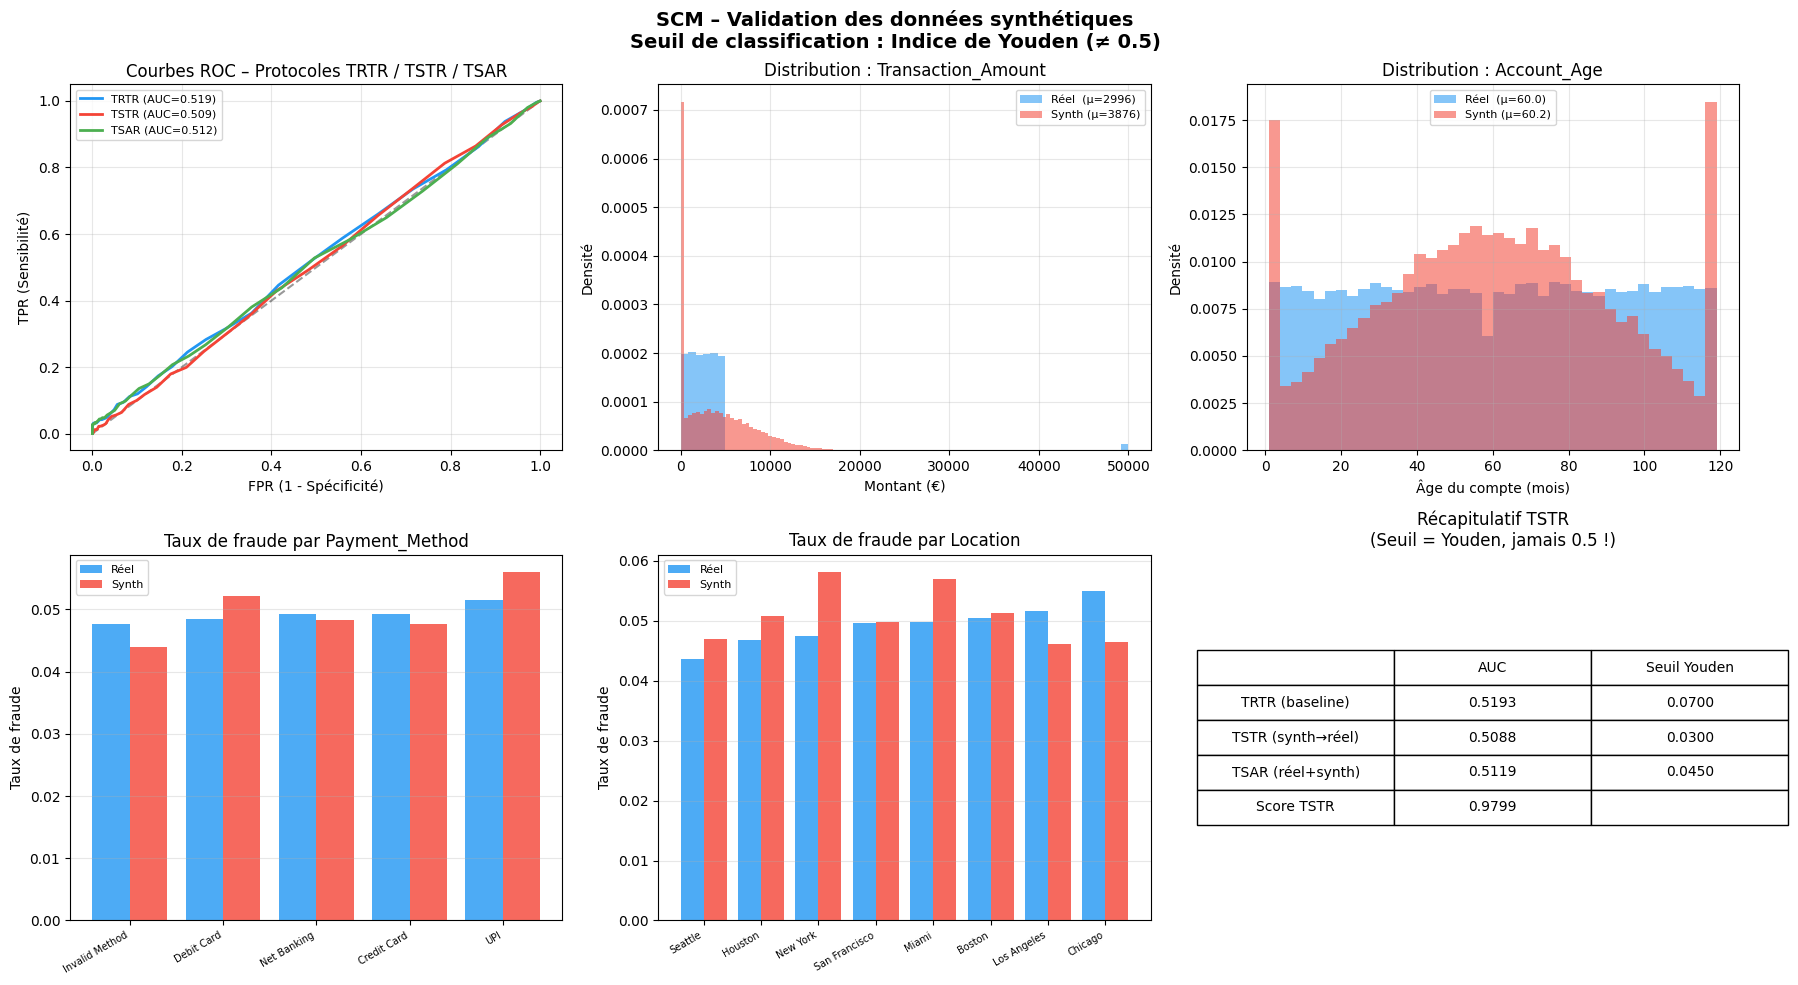


✅ Données synthétiques sauvegardées → donnees_synthetiques_scm.csv
   Shape  : (20000, 10)
   Fraude : 5.08%  (réel : 4.92%)

  Aperçu :
 Transaction_Amount Transaction_Type  Time_of_Transaction    Device_Used      Location  Previous_Fraudulent_Transactions  Account_Age  Number_of_Transactions_Last_24H Payment_Method  Fraudulent
        5501.642471     Bill Payment             3.093990         Mobile       Houston                          2.706704    52.782506                         5.922702    Net Banking           0
        2298.853975  Online Purchase            10.035883 Unknown Device      New York                          4.000000    46.263447                         8.447507    Net Banking           0
        6263.147087      POS Payment            20.520478        Desktop San Francisco                          1.669989   111.232605                         2.651225            UPI           0
       10678.309659  Online Purchase            14.996739        Desktop      New York

In [ ]:
"""
==============================================================================
GÉNÉRATION DE DONNÉES SYNTHÉTIQUES PAR MODÈLES CAUSAUX STRUCTURELS (SCM)
==============================================================================
Principe :
  1. On lit le DAG (dag_causal_fraude.json)
  2. Pour chaque nœud ENFANT (qui a des parents), on entraîne un mini-modèle :
       Parents  →  X   (features)
       Nœud     →  Y   (cible)
  3. On génère les données synthétiques en propageant dans l'ordre topologique
  4. Seuil de classification : Indice de Youden  (jamais 0.5 !)
  5. Variables continues : prédiction + jittering gaussien
  6. On sauvegarde uniquement le CSV des données synthétiques
==============================================================================
"""

# ──────────────────────────────────────────────────────────────────────────────
# IMPORTS
# ──────────────────────────────────────────────────────────────────────────────
import os, json, warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.linear_model    import LogisticRegression, LinearRegression
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.metrics         import roc_auc_score, roc_curve, recall_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble        import RandomForestClassifier

warnings.filterwarnings("ignore")
np.random.seed(42)


# ──────────────────────────────────────────────────────────────────────────────
# PARAMÈTRES  (seuls endroits à modifier) PROJET_STATAPP_MILLIMAN/
# ──────────────────────────────────────────────────────────────────────────────
#DAG_PATH  = "Génération de données synthétiques/LLM/dag_causal_fraude1.json"
DAG_PATH = "PROJET_STATAPP_MILLIMAN/Génération de données synthétiques/LLM/dag_causal_fraude.json"
DATA_PATH = "PROJET_STATAPP_MILLIMAN/Analyses_descriptives/Fraud Detection Dataset.csv"
OUTPUT_CSV = "donnees_synthetiques_scm.csv"

N_SYNTHETIC   = 20_000   # nombre de lignes à générer
JITTER_FACTOR = 0.05     # amplitude du bruit gaussien sur variables continues


# ──────────────────────────────────────────────────────────────────────────────
# ÉTAPE 1 — CHARGEMENT DU DAG ET DES DONNÉES RÉELLES
# ──────────────────────────────────────────────────────────────────────────────
print("=" * 60)
print("ÉTAPE 1 — Chargement du DAG et des données")
print("=" * 60)

with open(DAG_PATH, "r", encoding="utf-8") as f:
    dag = json.load(f)

# Colonnes utilisées = nœuds du DAG
NODES  = dag["noeuds"]
TARGET = "Fraudulent"
FEATS  = [n for n in NODES if n != TARGET]

# Données réelles — on garde uniquement les colonnes du DAG
df_real = pd.read_csv(DATA_PATH)[NODES].copy()
df_real = df_real.dropna(subset=[TARGET])

print(f"  DAG    : {len(NODES)} nœuds, {len(dag['liens'])} liens")
print(f"  Données: {df_real.shape[0]:,} lignes, taux fraude = {df_real[TARGET].mean():.2%}")

# Types de variables
CONTINUOUS   = ["Transaction_Amount", "Time_of_Transaction", "Account_Age",
                "Number_of_Transactions_Last_24H", "Previous_Fraudulent_Transactions"]
CATEGORICAL  = ["Transaction_Type", "Device_Used", "Location", "Payment_Method"]
BINARY       = ["Fraudulent"]

def var_type(col):
    if col in BINARY:      return "binary"
    if col in CONTINUOUS:  return "continuous"
    if col in CATEGORICAL: return "categorical"


# ──────────────────────────────────────────────────────────────────────────────
# ÉTAPE 2 — CONSTRUCTION DU GRAPHE ET ORDRE TOPOLOGIQUE
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ÉTAPE 2 — Analyse du graphe causal")
print("=" * 60)

G = nx.DiGraph()
G.add_nodes_from(NODES)
for lien in dag["liens"]:
    G.add_edge(lien["de"], lien["vers"])

assert nx.is_directed_acyclic_graph(G), "Le graphe n'est pas un DAG !"
print("  ✅ DAG valide (acyclique)")

parents = {n: list(G.predecessors(n)) for n in G.nodes()}
topo    = list(nx.topological_sort(G))

print("\n  Ordre topologique de génération :")
for n in topo:
    p = parents[n]
    tag = "🔴" if n == TARGET else ("🟡 RACINE" if not p else "🟢 enfant")
    print(f"    {tag}  {n}")
    if p:
        print(f"           ← parents : {p}")


# ──────────────────────────────────────────────────────────────────────────────
# ÉTAPE 3 — PRÉ-ENCODAGE DES CATÉGORIELLES
# ──────────────────────────────────────────────────────────────────────────────
# On encode les catégorielles en entiers pour pouvoir les passer aux modèles sklearn.
# On conserve les LabelEncoders pour décoder lors de la génération.

le_dict = {}          # LabelEncoder par variable catégorielle
df_enc  = df_real.copy()

for col in CATEGORICAL:
    le   = LabelEncoder()
    mask = df_enc[col].notna()
    le.fit(df_enc.loc[mask, col].astype(str))
    codes = le.transform(df_enc.loc[mask, col].astype(str)).astype(float)
    df_enc[col] = np.nan
    df_enc[col] = df_enc[col].astype(float)
    df_enc.loc[mask, col] = codes
    le_dict[col] = le


def make_X(df_src, parent_cols):
    """Construit la matrice features en imputant les NaN par la médiane."""
    X = df_src[parent_cols].copy().apply(pd.to_numeric, errors="coerce")
    for c in X.columns:
        med = X[c].median()
        X[c] = X[c].fillna(med if not np.isnan(med) else 0.0)
    arr = X.values.astype(float)
    # Imputation finale (sécurité)
    col_med = np.nanmedian(arr, axis=0)
    idx = np.where(np.isnan(arr))
    arr[idx] = col_med[idx[1]]
    return arr


# ──────────────────────────────────────────────────────────────────────────────
# ÉTAPE 4 — ENTRAÎNEMENT DES MINI-MODÈLES SCM
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ÉTAPE 4 — Entraînement des mini-modèles SCM")
print("          (un modèle par nœud enfant du DAG)")
print("=" * 60)

models   = {}   # modèle sklearn pour chaque nœud enfant
scalers  = {}   # StandardScaler associé
resid_std = {}  # écart-type des résidus (pour jittering)
youden_thresh = {}  # seuil Youden pour les nœuds binaires


def youden_threshold(y_true, y_prob):
    """
    Calcule le seuil optimal via l'indice de Youden.
    Youden = argmax(Sensibilité + Spécificité - 1) = argmax(TPR - FPR)

    ⚠️  On n'utilise JAMAIS le seuil par défaut 0.5 !
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    idx = np.argmax(tpr - fpr)
    return float(thresholds[idx])


for node in topo:
    p = parents[node]
    if not p:
        continue   # nœud racine → pas de modèle à entraîner

    vtype = var_type(node)
    print(f"\n  ── {node}  (type={vtype}, parents={p})")

    mask = df_enc[node].notna()
    X_all = make_X(df_enc[mask], p)
    y_all = df_enc.loc[mask, node].values.astype(float)

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42
    )

    sc = StandardScaler()
    X_tr_sc  = sc.fit_transform(X_tr)
    X_val_sc = sc.transform(X_val)
    scalers[node] = sc

    # ── Choix du modèle selon le type de variable ────────────────────────────
    if vtype == "binary":
        # ⚠️  class_weight=None → probabilités calibrées sur la vraie prévalence
        # (avec "balanced" les probas seraient biaisées vers 50%, ce qui ferait
        #  exploser le taux de fraude synthétique)
        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_tr_sc, y_tr)

        y_prob_val = model.predict_proba(X_val_sc)[:, 1]
        auc        = roc_auc_score(y_val, y_prob_val)

        # ⭐ Seuil de Youden (≠ 0.5)
        thresh = youden_threshold(y_val, y_prob_val)
        youden_thresh[node] = thresh

        y_pred = (y_prob_val >= thresh).astype(int)
        sens   = recall_score(y_val, y_pred, zero_division=0)
        spec   = recall_score(1 - y_val.astype(int), 1 - y_pred, zero_division=0)

        print(f"     Modèle  : Régression Logistique")
        print(f"     AUC val : {auc:.4f}")
        print(f"     ⭐ Seuil Youden = {thresh:.4f}  (Sensibilité={sens:.3f}, Spécificité={spec:.3f})")

    elif vtype == "categorical":
        model = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42)
        model.fit(X_tr_sc, y_tr)
        acc = model.score(X_val_sc, y_val)
        print(f"     Modèle  : Régression Logistique multiclasse")
        print(f"     Accuracy val : {acc:.4f}")

    elif vtype == "continuous":
        model = LinearRegression()
        model.fit(X_tr_sc, y_tr)
        r2  = model.score(X_val_sc, y_val)
        res = np.std(y_tr - model.predict(X_tr_sc))
        resid_std[node] = res
        print(f"     Modèle  : Régression Linéaire")
        print(f"     R² val  : {r2:.4f}   σ_résidus = {res:.4f}")

    models[node] = model

print(f"\n  ✅ {len(models)} mini-modèles SCM entraînés")


# ──────────────────────────────────────────────────────────────────────────────
# ÉTAPE 5 — GÉNÉRATION DES DONNÉES SYNTHÉTIQUES
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print(f"ÉTAPE 5 — Génération de {N_SYNTHETIC:,} observations synthétiques")
print("=" * 60)

synth = {}   # colonnes synthétiques construites progressivement

# ── 5.1  Nœuds racines : échantillonnage empirique ──────────────────────────
print("\n  [Racines] Échantillonnage depuis les distributions réelles")

for node in topo:
    if parents[node]:
        continue  # pas une racine

    vtype  = var_type(node)
    series = df_real[node].dropna()

    if vtype == "continuous":
        # Distribution normale calée sur les stats réelles
        vals = np.random.normal(series.mean(), series.std(), N_SYNTHETIC)
        vals = np.clip(vals, series.min(), series.max())
        synth[node] = vals
        print(f"    {node}: Normal(μ={series.mean():.1f}, σ={series.std():.1f})")

    else:  # categorical (Transaction_Type est une racine)
        freq  = series.astype(str).value_counts(normalize=True)
        vals  = np.random.choice(freq.index, size=N_SYNTHETIC, p=freq.values)
        synth[node] = vals
        print(f"    {node}: catégoriel ({len(freq)} modalités, empirique)")


# ── 5.2  Nœuds enfants : propagation causale (parent → enfant) ──────────────
print("\n  [Enfants] Propagation causale dans l'ordre topologique")

for node in topo:
    if node in synth:
        continue   # déjà généré (racine)

    p     = parents[node]
    vtype = var_type(node)
    model = models[node]
    sc    = scalers[node]

    # Construire la matrice X synthétique à partir des parents déjà générés
    cols = []
    for par in p:
        col_data = np.array(synth[par])
        if par in CATEGORICAL and par in le_dict:
            le = le_dict[par]
            col_data = np.array([
                le.transform([str(v)])[0] if str(v) in le.classes_
                else 0.0
                for v in col_data
            ], dtype=float)
        else:
            col_data = col_data.astype(float)
        cols.append(col_data.reshape(-1, 1))

    X_s    = np.hstack(cols)
    # Imputation NaN éventuelle
    col_med = np.nanmedian(X_s, axis=0)
    idx_nan = np.where(np.isnan(X_s))
    X_s[idx_nan] = col_med[idx_nan[1]]

    X_s_sc = sc.transform(X_s)

    # ── Inférence selon le type ──────────────────────────────────────────────
    if vtype == "binary":
        y_prob = model.predict_proba(X_s_sc)[:, 1]

        # Tirage Bernoulli(pᵢ) :
        #   • préserve les probabilités individuelles hétérogènes
        #   • maintient automatiquement le taux de fraude ≈ réel
        #   • Le seuil de Youden est utilisé pour l'ÉVALUATION (TSTR ci-dessous)
        y_gen = np.random.binomial(1, y_prob).astype(int)
        synth[node] = y_gen

        print(f"\n    {node}:")
        print(f"      Seuil Youden calculé : {youden_thresh[node]:.4f}  (≠ 0.5 !)")
        print(f"      Taux fraude synthétique : {y_gen.mean():.2%}  "
              f"(réel : {df_real[TARGET].mean():.2%})")

    elif vtype == "categorical":
        # Tirage multinomial sur les probabilités prédites
        # → plus réaliste qu'un argmax déterministe
        proba  = model.predict_proba(X_s_sc)
        le     = le_dict[node]
        codes  = np.array([np.random.choice(len(le.classes_), p=row) for row in proba])
        y_gen  = le.inverse_transform(codes)
        synth[node] = y_gen

        print(f"\n    {node}:")
        real_freq  = df_real[node].value_counts(normalize=True)
        synth_freq = pd.Series(y_gen).value_counts(normalize=True)
        for cat in le.classes_:
            r = real_freq.get(cat, 0)
            s = synth_freq.get(cat, 0)
            print(f"      {str(cat):25s}  réel={r:.1%}  synth={s:.1%}")

    elif vtype == "continuous":
        y_pred = model.predict(X_s_sc)
        sigma  = resid_std.get(node, 1.0)
        # Jittering gaussien : rend les données moins déterministes
        noise  = np.random.normal(0, JITTER_FACTOR * sigma, N_SYNTHETIC)
        y_gen  = np.clip(y_pred + noise,
                         df_real[node].min(),
                         df_real[node].max())
        synth[node] = y_gen
        print(f"\n    {node}: μ={y_gen.mean():.2f} (réel={df_real[node].mean():.2f})"
              f"  σ={y_gen.std():.2f} (réel={df_real[node].std():.2f})")

# Assembler le DataFrame final dans l'ordre des colonnes du DAG
df_synth = pd.DataFrame(synth)[NODES]

print(f"\n  ✅ Données synthétiques : {df_synth.shape}")
print(f"  Taux de fraude : {df_synth[TARGET].mean():.2%}  (réel : {df_real[TARGET].mean():.2%})")


# ──────────────────────────────────────────────────────────────────────────────
# ÉTAPE 6 — VALIDATION TSTR  (Train Synthetic, Test Real)
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ÉTAPE 6 — Validation TSTR  (Train Synthetic / Test Real)")
print("=" * 60)
print("""
  Si TSTR ≈ TRTR  →  données synthétiques de bonne qualité
  Si TSTR > TRTR  →  données synthétiques encore plus utiles
  Seuil de classification : toujours Youden (jamais 0.5 !)
""")


def encode_df(df_in):
    """Encode catégorielles + impute NaN pour sklearn."""
    df_out = df_in.copy()
    for col in CATEGORICAL:
        if col not in df_out.columns:
            continue
        df_out[col] = df_out[col].fillna("MISSING").astype(str)
        le = le_dict.get(col)
        if le:
            known = set(le.classes_)
            df_out[col] = df_out[col].apply(lambda x: x if x in known else le.classes_[0])
            df_out[col] = le.transform(df_out[col])
        else:
            from sklearn.preprocessing import LabelEncoder as LE
            df_out[col] = LE().fit_transform(df_out[col])
    for col in CONTINUOUS:
        if col in df_out.columns:
            df_out[col] = pd.to_numeric(df_out[col], errors="coerce").fillna(0)
    return df_out


def eval_model(model, X_test, y_test, label):
    """Évalue avec seuil Youden."""
    y_prob = model.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    thresh = float(thresholds[np.argmax(tpr - fpr)])
    y_pred = (y_prob >= thresh).astype(int)
    sens   = recall_score(y_test, y_pred, zero_division=0)
    spec   = recall_score(1 - y_test, 1 - y_pred, zero_division=0)
    print(f"  {label:35s}  AUC={auc:.4f}  Seuil={thresh:.4f}"
          f"  Sens={sens:.3f}  Spéc={spec:.3f}")
    return auc, y_prob, thresh


rf = dict(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)

# Données réelles encodées
df_re = encode_df(df_real)
X_r   = df_re[FEATS].values.astype(float)
y_r   = df_re[TARGET].values.astype(int)
X_tr, X_te, y_tr, y_te = train_test_split(X_r, y_r, test_size=0.2,
                                           random_state=42, stratify=y_r)

# Données synthétiques encodées
df_se = encode_df(df_synth)
X_s   = df_se[FEATS].values.astype(float)
y_s   = df_se[TARGET].values.astype(int)

sc_v    = StandardScaler()
X_tr_sc = sc_v.fit_transform(X_tr)
X_te_sc = sc_v.transform(X_te)
X_s_sc  = sc_v.transform(X_s)

# TRTR : baseline
m_trtr = RandomForestClassifier(**rf)
m_trtr.fit(X_tr, y_tr)
auc_trtr, prob_trtr, t_trtr = eval_model(m_trtr, X_te, y_te, "TRTR (baseline réel→réel)")

# TSTR : entraîné sur synthétique
m_tstr = RandomForestClassifier(**rf)
m_tstr.fit(X_s_sc, y_s)
auc_tstr, prob_tstr, t_tstr = eval_model(m_tstr, X_te_sc, y_te, "TSTR (synth→réel)")

# TSAR : réel + synthétique
X_aug = np.vstack([X_tr_sc, X_s_sc])
y_aug = np.concatenate([y_tr, y_s])
m_tsar = RandomForestClassifier(**rf)
m_tsar.fit(X_aug, y_aug)
auc_tsar, prob_tsar, t_tsar = eval_model(m_tsar, X_te_sc, y_te, "TSAR  (réel+synth→réel)")

tstr_score = auc_tstr / auc_trtr
print(f"\n  ⭐ Score TSTR = {auc_tstr:.4f} / {auc_trtr:.4f} = {tstr_score:.4f}")


# ──────────────────────────────────────────────────────────────────────────────
# ÉTAPE 7 — VISUALISATIONS  (affichées, non sauvegardées)
# ──────────────────────────────────────────────────────────────────────────────
print("\n  Affichage des graphiques...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("SCM – Validation des données synthétiques\n"
             "Seuil de classification : Indice de Youden (≠ 0.5)",
             fontsize=14, fontweight="bold")

# ── Plot 1 : Courbes ROC ─────────────────────────────────────────────────────
ax = axes[0, 0]
ax.set_title("Courbes ROC – Protocoles TRTR / TSTR / TSAR")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
for prob, model, X_test, y_test, label, color in [
    (prob_trtr, m_trtr, X_te,    y_te, f"TRTR (AUC={auc_trtr:.3f})", "#2196F3"),
    (prob_tstr, m_tstr, X_te_sc, y_te, f"TSTR (AUC={auc_tstr:.3f})", "#F44336"),
    (prob_tsar, m_tsar, X_te_sc, y_te, f"TSAR (AUC={auc_tsar:.3f})", "#4CAF50"),
]:
    from sklearn.metrics import roc_curve as rc
    fpr, tpr, _ = rc(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=label)
ax.set_xlabel("FPR (1 - Spécificité)"); ax.set_ylabel("TPR (Sensibilité)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 2 : Distribution Transaction_Amount ─────────────────────────────────
ax = axes[0, 1]
ax.set_title("Distribution : Transaction_Amount")
real_ta  = df_real["Transaction_Amount"].dropna()
synth_ta = pd.to_numeric(df_synth["Transaction_Amount"], errors="coerce").dropna()
ax.hist(real_ta,  bins=60, alpha=0.55, color="#2196F3", density=True,
        label=f"Réel  (μ={real_ta.mean():.0f})")
ax.hist(synth_ta, bins=60, alpha=0.55, color="#F44336", density=True,
        label=f"Synth (μ={synth_ta.mean():.0f})")
ax.set_xlabel("Montant (€)"); ax.set_ylabel("Densité")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 3 : Distribution Account_Age ────────────────────────────────────────
ax = axes[0, 2]
ax.set_title("Distribution : Account_Age")
real_aa  = df_real["Account_Age"].dropna()
synth_aa = pd.to_numeric(df_synth["Account_Age"], errors="coerce").dropna()
ax.hist(real_aa,  bins=40, alpha=0.55, color="#2196F3", density=True,
        label=f"Réel  (μ={real_aa.mean():.1f})")
ax.hist(synth_aa, bins=40, alpha=0.55, color="#F44336", density=True,
        label=f"Synth (μ={synth_aa.mean():.1f})")
ax.set_xlabel("Âge du compte (mois)"); ax.set_ylabel("Densité")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Plot 4 : Taux de fraude par Payment_Method ───────────────────────────────
ax = axes[1, 0]
ax.set_title("Taux de fraude par Payment_Method")
real_pm  = df_real.groupby("Payment_Method")[TARGET].mean().sort_values()
synth_pm = (df_synth.groupby("Payment_Method")[TARGET].mean()
            .reindex(real_pm.index, fill_value=0))
x = np.arange(len(real_pm))
ax.bar(x - 0.2, real_pm.values,  0.4, color="#2196F3", alpha=0.8, label="Réel")
ax.bar(x + 0.2, synth_pm.values, 0.4, color="#F44336", alpha=0.8, label="Synth")
ax.set_xticks(x); ax.set_xticklabels(real_pm.index, rotation=30, ha="right", fontsize=7)
ax.set_ylabel("Taux de fraude"); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

# ── Plot 5 : Taux de fraude par Location ─────────────────────────────────────
ax = axes[1, 1]
ax.set_title("Taux de fraude par Location")
real_loc  = df_real.groupby("Location")[TARGET].mean().sort_values()
synth_loc = (df_synth.groupby("Location")[TARGET].mean()
             .reindex(real_loc.index, fill_value=0))
x = np.arange(len(real_loc))
ax.bar(x - 0.2, real_loc.values,  0.4, color="#2196F3", alpha=0.8, label="Réel")
ax.bar(x + 0.2, synth_loc.values, 0.4, color="#F44336", alpha=0.8, label="Synth")
ax.set_xticks(x); ax.set_xticklabels(real_loc.index, rotation=30, ha="right", fontsize=7)
ax.set_ylabel("Taux de fraude"); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

# ── Plot 6 : Tableau récapitulatif ───────────────────────────────────────────
ax = axes[1, 2]
ax.axis("off")
summary = [
    ["", "AUC", "Seuil Youden"],
    ["TRTR (baseline)", f"{auc_trtr:.4f}", f"{t_trtr:.4f}"],
    ["TSTR (synth→réel)", f"{auc_tstr:.4f}", f"{t_tstr:.4f}"],
    ["TSAR (réel+synth)", f"{auc_tsar:.4f}", f"{t_tsar:.4f}"],
    ["Score TSTR", f"{tstr_score:.4f}", ""],
]
table = ax.table(cellText=summary[1:], colLabels=summary[0],
                 loc="center", cellLoc="center")
table.auto_set_font_size(False); table.set_fontsize(10)
table.scale(1.2, 2)
ax.set_title("Récapitulatif TSTR\n(Seuil = Youden, jamais 0.5 !)")

plt.tight_layout()
plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# ÉTAPE 8 — SAUVEGARDE (uniquement le CSV des données synthétiques)
# ──────────────────────────────────────────────────────────────────────────────
df_synth.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ Données synthétiques sauvegardées → {OUTPUT_CSV}")
print(f"   Shape  : {df_synth.shape}")
print(f"   Fraude : {df_synth[TARGET].mean():.2%}  (réel : {df_real[TARGET].mean():.2%})")
print(f"\n  Aperçu :\n{df_synth.head(5).to_string(index=False)}")


In [11]:
pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 79.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


PROJET_STATAPP_MILLIMAN/

In [21]:
import warnings; warnings.filterwarnings('ignore')
import json, numpy as np, pandas as pd, networkx as nx
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split

np.random.seed(42)

# ── CHEMINS ───────────────────────────────────────────────────────────────────
DAG_PATH  = "PROJET_STATAPP_MILLIMAN/Génération de données synthétiques/LLM/dag_causal_fraude.json"
DATA_PATH = "PROJET_STATAPP_MILLIMAN/Analyses_descriptives/Fraud Detection Dataset.csv"
OUTPUT    = "fraudes_synthetiques_dag.csv"
N         = 15_000    # fraudes à générer
BATCH     = 50_000   # taille du batch

# ── CHARGEMENT ────────────────────────────────────────────────────────────────
dag   = json.load(open(DAG_PATH, encoding="utf-8"))
NODES = dag["noeuds"]; TARGET = "Fraudulent"
CONT  = ["Transaction_Amount","Time_of_Transaction","Account_Age",
         "Number_of_Transactions_Last_24H","Previous_Fraudulent_Transactions"]
CAT   = ["Transaction_Type","Device_Used","Location","Payment_Method"]

df = pd.read_csv(DATA_PATH)[NODES].dropna(subset=[TARGET])
print(f"Data: {len(df):,}  fraude={df[TARGET].mean():.2%}")

G = nx.DiGraph(); G.add_nodes_from(NODES)
for l in dag["liens"]: G.add_edge(l["de"], l["vers"])
parents = {n: list(G.predecessors(n)) for n in G.nodes()}
topo    = list(nx.topological_sort(G))

# ── ENCODAGE ──────────────────────────────────────────────────────────────────
le_dict = {}; df_enc = df.copy()
for col in CAT:
    le = LabelEncoder(); mask = df_enc[col].notna()
    le.fit(df_enc.loc[mask, col].astype(str))
    codes = le.transform(df_enc.loc[mask, col].astype(str)).astype(float)
    df_enc[col] = np.nan; df_enc[col] = df_enc[col].astype(float)
    df_enc.loc[mask, col] = codes; le_dict[col] = le

def make_X(src, cols):
    X = src[cols].copy().apply(pd.to_numeric, errors="coerce").values.astype(float)
    for j in range(X.shape[1]):
        m = np.nanmedian(X[:, j])
        X[np.isnan(X[:, j]), j] = m if not np.isnan(m) else 0.
    return X

def youden(yt, yp):
    fpr, tpr, th = roc_curve(yt, yp)
    return float(th[np.argmax(tpr - fpr)])

# ── ENTRAÎNEMENT ──────────────────────────────────────────────────────────────
models = {}; scalers = {}; seuil_youden = None
print("\n=== ENTRAÎNEMENT ===")
for node in topo:
    p = parents[node]
    if not p: continue
    vt = "binary" if node == TARGET else "categorical"
    mask = df_enc[node].notna()
    X = make_X(df_enc[mask], p)
    Y = df_enc.loc[mask, node].values.astype(float)
    Xtr, Xv, Ytr, Yv = train_test_split(X, Y, test_size=0.2, random_state=42)
    sc = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr); Xv_sc = sc.transform(Xv)
    scalers[node] = sc
    if vt == "binary":
        m = LogisticRegression(C=10, max_iter=2000)
        m.fit(Xtr_sc, Ytr)
        yp = m.predict_proba(Xv_sc)[:, 1]
        s  = youden(Yv, yp); seuil_youden = s
        print(f"  {node}: Seuil Youden={s:.4f}")
    else:
        m = LogisticRegression(C=1, max_iter=2000)
        m.fit(Xtr_sc, Ytr)
        print(f"  {node}: acc={m.score(Xv_sc, Yv):.4f}")
    models[node] = m

# ── GÉNÉRATION PAR REJET (vectorisée) ────────────────────────────────────────
print(f"\n=== GÉNÉRATION  seuil={seuil_youden:.4f} ===")

def encode_col(vals, col):
    """Encode une colonne catégorielle en codes numériques (vectorisé)."""
    le = le_dict[col]
    vals = np.array(vals).astype(str)
    known = np.isin(vals, le.classes_)
    codes = np.zeros(len(vals))
    codes[known]  = le.transform(vals[known])
    codes[~known] = 0
    return codes.astype(float)

def sample_categ(proba, n_classes):
    """Tirage multinomial vectorisé — remplace le for loop."""
    cumul = np.cumsum(proba, axis=1)
    r     = np.random.rand(len(proba), 1)
    return (r > cumul).sum(axis=1).clip(0, n_classes - 1)

all_rows = []; it = 0
while len(all_rows) < N and it < 30:
    it += 1; batch = {}

    # Racines
    for node in topo:
        if parents[node]: continue
        s2 = df[node].dropna()
        if node in CONT:
            batch[node] = s2.sample(BATCH, replace=True, random_state=it).values
        else:
            freq = s2.astype(str).value_counts(normalize=True)
            batch[node] = np.random.choice(freq.index, BATCH, p=freq.values)

    # Enfants catégoriels
    for node in topo:
        if node in batch or node == TARGET: continue
        cols2 = [encode_col(batch[par], par) if par in CAT
                 else batch[par].astype(float)
                 for par in parents[node]]
        Xs = np.column_stack(cols2)
        nn = np.where(np.isnan(Xs)); Xs[nn] = np.nanmedian(Xs, axis=0)[nn[1]]
        pr = models[node].predict_proba(scalers[node].transform(Xs))
        # Tirage vectorisé (pas de for loop !)
        codes = sample_categ(pr, pr.shape[1])
        batch[node] = le_dict[node].inverse_transform(codes.astype(int))

    # Fraudulent — calcul P et rejet
    cols3 = [encode_col(batch[par], par) if par in CAT
             else batch[par].astype(float)
             for par in parents[TARGET]]
    Xf = np.column_stack(cols3)
    nn = np.where(np.isnan(Xf)); Xf[nn] = np.nanmedian(Xf, axis=0)[nn[1]]
    yp = models[TARGET].predict_proba(scalers[TARGET].transform(Xf))[:, 1]
    mf = yp >= seuil_youden

    if mf.sum() > 0:
        feats = [n for n in NODES if n != TARGET]
        db = pd.DataFrame({c: batch[c][mf] for c in feats})
        db[TARGET] = 1; all_rows.append(db)

    ntot = sum(len(d) for d in all_rows)
    print(f"  Batch {it}: gardé={mf.sum():,} ({mf.mean()*100:.1f}%)  total={ntot:,}/{N}")
    if ntot >= N: break

df_synth = pd.concat(all_rows, ignore_index=True).head(N)
df_synth[TARGET] = 1
df_synth.to_csv(OUTPUT, index=False)
print(f"\n✅ {len(df_synth):,} fraudes  —  Fraudulent=1 partout")
print(df_synth.head(3).to_string(index=False))

Data: 51,000  fraude=4.92%

=== ENTRAÎNEMENT ===
  Device_Used: acc=0.3187
  Payment_Method: acc=0.2462
  Location: acc=0.1212
  Fraudulent: Seuil Youden=0.0476

=== GÉNÉRATION  seuil=0.0476 ===
  Batch 1: gardé=32,129 (64.3%)  total=32,129/15000

✅ 15,000 fraudes  —  Fraudulent=1 partout
 Transaction_Amount Transaction_Type  Time_of_Transaction Device_Used Location  Previous_Fraudulent_Transactions  Account_Age  Number_of_Transactions_Last_24H Payment_Method  Fraudulent
            1800.11    Bank Transfer                 11.0      Tablet   Boston                                 0           48                               12    Net Banking           1
            1752.48  Online Purchase                 11.0      Mobile    Miami                                 2           37                                4    Net Banking           1
            1029.40     Bill Payment                 21.0      Mobile  Seattle                                 4           88                           